# 1.4 — SDEs: soluciones exactas, Euler-Maruyama, Milstein y convergencia

## Motivación

Casi ningún modelo de pricing se resuelve en forma cerrada más allá de GBM y un puñado de casos especiales (OU, CIR, Heston con Fourier). En la práctica, valuar un derivado bajo un modelo de tasa corta, un modelo de volatilidad estocástica o cualquier SDE con coeficientes no lineales requiere **simular** trayectorias — y simular bien requiere entender qué esquema de discretización usar, qué error introduce, y a qué velocidad ese error desaparece cuando refinamos la malla temporal. Este notebook cubre las tres SDEs canónicas de finanzas cuantitativas —movimiento geométrico browniano (GBM, el motor de Black-Scholes), Ornstein-Uhlenbeck (OU, la base de Vasicek y de tasas mean-reverting) y Cox-Ingersoll-Ross (CIR, la base de CIR/Heston con positividad garantizada bajo Feller)— derivamos sus soluciones exactas cuando existen, y construimos desde cero los esquemas de Euler-Maruyama y Milstein que se usan cuando no existen.

La pregunta que distingue a un practicante cuidadoso de uno que solo copia código es: *¿cuántos pasos necesito?* Contestarla requiere el concepto de **orden de convergencia** — fuerte (qué tan cerca está una trayectoria simulada de la trayectoria "verdadera" acoplada al mismo camino browniano) y débil (qué tan cerca está la distribución simulada, relevante para pricing donde solo importa $\mathbb{E}[\text{payoff}]$). Euler-Maruyama converge fuertemente a orden $0.5$; Milstein, al incorporar un término de corrección de segundo orden en el ruido, converge a orden $1.0$ — una mejora que se paga con una derivada extra del coeficiente de difusión. Estos órdenes son la razón práctica por la que Milstein (o esquemas de orden superior) valen la pena cuando el error de discretización domina el presupuesto de cómputo, y son el punto de partida de Multilevel Monte Carlo (Giles 2008), que explota exactamente esta tasa de convergencia para reducir varianza.

Cubrimos: (i) SDEs y la noción de solución fuerte; (ii) GBM — solución exacta vía el lema de Itô; (iii) OU — solución exacta vía factor integrante, media/varianza/distribución estacionaria; (iv) CIR — propiedades y la condición de Feller (enunciado); (v) discretización de Euler-Maruyama y Milstein, con la derivación del término de corrección; (vi) convergencia fuerte y débil — definiciones y órdenes teóricos, verificados numéricamente.

## 1. SDEs y soluciones fuertes

Una **ecuación diferencial estocástica** (SDE) tiene la forma
$$
dX_t = a(X_t, t)\,dt + b(X_t, t)\,dW_t, \qquad X_0 = x_0,
$$
que es notación abreviada para la ecuación integral
$$
X_t = x_0 + \int_0^t a(X_s, s)\,ds + \int_0^t b(X_s, s)\,dW_s,
$$
donde la segunda integral es una integral de Itô (01.3). $a(\cdot)$ se llama el coeficiente de **deriva** (drift) y $b(\cdot)$ el coeficiente de **difusión**.

**Solución fuerte.** Un proceso $(X_t)$ adaptado a la filtración generada por $(W_t)$ es una **solución fuerte** si satisface la ecuación integral casi seguramente para el camino browniano dado — es decir, $X_t$ es una función (medible) del camino $\{W_s: s\le t\}$ realizado. Esto contrasta con una solución *débil*, donde solo se exige que exista *algún* par $(X_t, W_t)$ en *algún* espacio de probabilidad que satisfaga la ecuación, sin que $X_t$ sea función del $W_t$ dado de antemano. Para simular necesitamos soluciones fuertes: generamos un camino browniano concreto (vía sus incrementos gaussianos) y evaluamos $X_t$ sobre ese camino.

**Teorema (existencia y unicidad, enunciado).** Si $a$ y $b$ son Lipschitz en $x$ (uniformemente en $t$) y satisfacen una condición de crecimiento lineal $|a(x,t)|+|b(x,t)| \le C(1+|x|)$, entonces la SDE tiene una única solución fuerte con $\mathbb{E}\big[\int_0^T X_t^2\,dt\big] < \infty$. No lo demostramos (ver Kloeden-Platen, cap. 4.5, prueba por iteración de Picard); GBM y OU satisfacen las hipótesis globalmente. CIR no —$b(x)=\sigma\sqrt{x}$ no es Lipschitz cerca de $x=0$— pero existe una versión más fina del teorema (coeficientes Hölder-$1/2$ más monotonía) que sí garantiza solución fuerte única y no negativa; ver sección 4.

## 2. Movimiento geométrico browniano (GBM): solución exacta

$$
dS_t = \mu S_t\,dt + \sigma S_t\,dW_t, \qquad S_0 > 0.
$$

Aplicamos el lema de Itô (01.3) a $f(x) = \ln x$, con $f'(x)=1/x$, $f''(x)=-1/x^2$:
$$
d(\ln S_t) = \frac{1}{S_t}\,dS_t - \frac{1}{2}\frac{1}{S_t^2}\,d\langle S\rangle_t
= \frac{1}{S_t}\big(\mu S_t\,dt + \sigma S_t\,dW_t\big) - \frac{1}{2S_t^2}\,\sigma^2 S_t^2\,dt
= \left(\mu - \frac{\sigma^2}{2}\right)dt + \sigma\,dW_t,
$$
usando $d\langle S\rangle_t = \sigma^2 S_t^2\,dt$ (variación cuadrática de una difusión Itô). El lado derecho ya no tiene $S_t$: es una SDE trivial (drift y difusión constantes), que integramos directamente de $0$ a $t$:
$$
\ln S_t - \ln S_0 = \left(\mu - \frac{\sigma^2}{2}\right)t + \sigma W_t \quad\Longrightarrow\quad
\boxed{S_t = S_0 \exp\!\left[\left(\mu - \frac{\sigma^2}{2}\right)t + \sigma W_t\right]}.
$$

$S_t$ es **lognormal**: $\ln S_t \sim \mathcal{N}\big(\ln S_0 + (\mu-\sigma^2/2)t,\ \sigma^2 t\big)$, de donde $\mathbb{E}[S_t] = S_0 e^{\mu t}$ (la media crece a tasa $\mu$, no $\mu-\sigma^2/2$ — el ajuste de convexidad de Jensen compensa exactamente el término $-\sigma^2/2$) y $\text{Var}(S_t) = S_0^2 e^{2\mu t}\big(e^{\sigma^2 t}-1\big)$.

**Esquema exacto (log-Euler).** Como la solución solo depende del incremento browniano, no de la trayectoria intermedia, podemos simular $S_t$ *sin error de discretización* en cualquier malla $0=t_0<t_1<\dots<t_n$:
$$
S_{t_{k+1}} = S_{t_k}\exp\!\left[\left(\mu-\frac{\sigma^2}{2}\right)h_k + \sigma\sqrt{h_k}\,Z_k\right], \qquad Z_k\stackrel{iid}{\sim}\mathcal{N}(0,1),\ h_k = t_{k+1}-t_k.
$$
Esto es exacto en cada paso (no solo en el límite $h\to0$) porque $W_{t_{k+1}}-W_{t_k}\sim\mathcal{N}(0,h_k)$ exactamente. Este esquema es el que promovemos como `gbm_paths` en `qflib.mc`.

## 3. Proceso de Ornstein-Uhlenbeck (OU): solución exacta

$$
dX_t = \kappa(\theta - X_t)\,dt + \sigma\,dW_t, \qquad \kappa,\sigma>0.
$$

$X_t$ revierte a la media $\theta$ a velocidad $\kappa$: es el modelo de Vasicek para tasas cortas. A diferencia de GBM, el drift depende de $X_t$ de forma *lineal* pero no multiplicativa, así que no podemos usar Itô en $\ln X_t$; en su lugar usamos el **factor integrante** $e^{\kappa t}$, el mismo truco de EDOs lineales de primer orden. Por la regla del producto de Itô (con $d\langle X, \text{constante}\rangle=0$, así que aquí es la regla del producto ordinaria porque $e^{\kappa t}$ es determinista):
$$
d\big(e^{\kappa t}X_t\big) = \kappa e^{\kappa t}X_t\,dt + e^{\kappa t}\,dX_t = \kappa e^{\kappa t}X_t\,dt + e^{\kappa t}\big[\kappa(\theta-X_t)dt+\sigma\,dW_t\big] = \kappa\theta e^{\kappa t}\,dt + \sigma e^{\kappa t}\,dW_t.
$$
Los términos en $X_t$ se cancelan — ese es el punto del factor integrante. Integrando de $0$ a $t$:
$$
e^{\kappa t}X_t - X_0 = \theta\big(e^{\kappa t}-1\big) + \sigma\int_0^t e^{\kappa s}\,dW_s
\quad\Longrightarrow\quad
\boxed{X_t = X_0 e^{-\kappa t} + \theta\big(1-e^{-\kappa t}\big) + \sigma e^{-\kappa t}\int_0^t e^{\kappa s}\,dW_s}.
$$

La integral estocástica es una integral de Wiener con integrando determinista, luego $X_t$ es **gaussiano**. Su media es directa (la integral tiene media cero):
$$
\mathbb{E}[X_t] = X_0 e^{-\kappa t} + \theta\big(1-e^{-\kappa t}\big).
$$
Su varianza usa la isometría de Itô, $\text{Var}\big(\int_0^t f(s)dW_s\big) = \int_0^t f(s)^2\,ds$ con $f(s)=\sigma e^{-\kappa t}e^{\kappa s}$:
$$
\text{Var}(X_t) = \sigma^2 e^{-2\kappa t}\int_0^t e^{2\kappa s}\,ds = \sigma^2 e^{-2\kappa t}\cdot\frac{e^{2\kappa t}-1}{2\kappa} = \frac{\sigma^2}{2\kappa}\big(1-e^{-2\kappa t}\big).
$$

**Distribución estacionaria.** Cuando $t\to\infty$, $\mathbb{E}[X_t]\to\theta$ y $\text{Var}(X_t)\to \sigma^2/(2\kappa)$, así que
$$
X_\infty \sim \mathcal{N}\!\left(\theta,\ \frac{\sigma^2}{2\kappa}\right).
$$

**Esquema exacto (gaussiano).** Como $X_t$ es un proceso de Markov gaussiano, la transición $X_{t_k}\to X_{t_{k+1}}$ es también gaussiana y exacta, sin límite $h\to0$:
$$
X_{t_{k+1}} = X_{t_k}e^{-\kappa h_k} + \theta\big(1-e^{-\kappa h_k}\big) + \sigma\sqrt{\frac{1-e^{-2\kappa h_k}}{2\kappa}}\,Z_k, \qquad Z_k\stackrel{iid}{\sim}\mathcal{N}(0,1).
$$
Este es el esquema promovido como `ou_paths` en `qflib.mc`.

## 4. Proceso CIR y condición de Feller

$$
dX_t = \kappa(\theta - X_t)\,dt + \sigma\sqrt{X_t}\,dW_t, \qquad X_0 \ge 0.
$$

CIR comparte el drift de mean-reversion de OU pero la difusión $\sigma\sqrt{X_t}$ se anula cuando $X_t\to0$, lo que empuja al proceso de vuelta hacia territorio positivo (el ruido desaparece justo donde podría empujarlo a negativo). No hay solución fuerte cerrada en términos elementales de $(t, W_t)$ como GBM u OU —$X_t$ sigue una distribución **chi-cuadrada no central** escalada—, pero sí conocemos su media y varianza exactas (idénticas en forma a OU para la media, porque el drift es el mismo):
$$
\mathbb{E}[X_t] = X_0 e^{-\kappa t} + \theta(1-e^{-\kappa t}), \qquad
\text{Var}(X_t) = X_0\frac{\sigma^2}{\kappa}\big(e^{-\kappa t}-e^{-2\kappa t}\big) + \theta\frac{\sigma^2}{2\kappa}\big(1-e^{-\kappa t}\big)^2.
$$

**Condición de Feller (enunciado).** El proceso CIR permanece estrictamente positivo para todo $t>0$ (nunca toca $0$) si y solo si
$$
2\kappa\theta \ge \sigma^2.
$$
Intuición: $2\kappa\theta$ mide la fuerza con la que el drift empuja hacia arriba cerca de $x=0$ (donde $\kappa(\theta-x)\approx\kappa\theta$), mientras $\sigma^2$ mide la intensidad del ruido difusivo cerca de $0$; si el drift domina, la barrera en $0$ es inalcanzable. No demostramos la condición (la prueba usa escalas de tiempo de Feller / criterios de Feller para difusiones unidimensionales; ver Feller 1951, o Lamberton-Lapeyre cap. 6); la demo 3 la verifica numéricamente contando truncamientos.

Cuando la condición se viola, $X_t$ puede tocar $0$ (y, dependiendo de la especificación de frontera, reflejarse o quedar absorbido); en la práctica, el esquema de discretización debe manejar este caso explícitamente para no evaluar $\sqrt{X_t}$ en un número negativo — de ahí el esquema de "truncamiento completo" de la siguiente sección.

## 5. Discretización: Euler-Maruyama y Milstein

Para una SDE general $dX_t = a(X_t)\,dt + b(X_t)\,dW_t$ sin solución cerrada, discretizamos en una malla $t_k = kh$ con incrementos brownianos $\Delta W_k = W_{t_{k+1}}-W_{t_k}\sim\mathcal{N}(0,h)$.

### 5.1 Euler-Maruyama (EM)

El esquema más simple congela $a$ y $b$ en el valor conocido al inicio del paso:
$$
X_{k+1} = X_k + a(X_k)\,h + b(X_k)\,\Delta W_k.
$$
Es el análogo estocástico de Euler explícito para EDOs, con el término adicional de ruido. Es exacto a primer orden en el drift (Taylor determinista) pero solo a "medio orden" en el ruido, como se cuantifica en la sección 6.

### 5.2 Milstein: derivación del término de corrección

Milstein mejora EM incorporando el siguiente término del desarrollo de Taylor estocástico (Itô-Taylor) aplicado al *coeficiente de difusión* $b(X_s)$ dentro del paso. Partimos de la ecuación integral exacta en $[t_k, t_k+h]$:
$$
X_{t_k+h} = X_k + \int_{t_k}^{t_k+h} a(X_s)\,ds + \int_{t_k}^{t_k+h} b(X_s)\,dW_s.
$$
EM aproxima $b(X_s)\approx b(X_k)$ dentro de la segunda integral. Para capturar el siguiente orden, expandimos $b(X_s)$ con el lema de Itô alrededor de $s=t_k$:
$$
b(X_s) \approx b(X_k) + b'(X_k)\big(X_s - X_k\big) \approx b(X_k) + b'(X_k)\,b(X_k)\int_{t_k}^{s} dW_u,
$$
donde en el último paso solo retenemos el término dominante de $X_s-X_k$ (la parte de ruido $b(X_k)\Delta W$, que es $O(\sqrt{h})$ y domina sobre el drift $O(h)$). Sustituyendo en la integral estocástica:
$$
\int_{t_k}^{t_k+h} b(X_s)\,dW_s \approx b(X_k)\Delta W_k + b'(X_k)b(X_k)\int_{t_k}^{t_k+h}\left(\int_{t_k}^{s}dW_u\right)dW_s.
$$
La integral doble se evalúa con la identidad de Itô $\int_{t_k}^{t_k+h}(W_s-W_{t_k})\,dW_s = \tfrac12\big[(\Delta W_k)^2 - h\big]$ (consecuencia directa de aplicar Itô a $f(x)=x^2/2$ sobre $W_s-W_{t_k}$, igual que en 01.3). Sustituyendo:
$$
\boxed{X_{k+1} = X_k + a(X_k)\,h + b(X_k)\,\Delta W_k + \frac12\,b(X_k)\,b'(X_k)\big[(\Delta W_k)^2 - h\big]}.
$$
El término extra respecto a EM es el **término de corrección de Milstein**: desaparece en media ($\mathbb{E}[(\Delta W_k)^2 - h]=0$) pero reduce la varianza del error al capturar la curvatura de $b$ en cada trayectoria individual — de ahí la mejora en convergencia *fuerte* (trayectoria por trayectoria), no en convergencia débil (donde EM ya es de orden 1, ver sección 6).

Para GBM, $b(x)=\sigma x \Rightarrow b'(x)=\sigma$, y el esquema de Milstein es
$$
S_{k+1} = S_k + \mu S_k h + \sigma S_k \Delta W_k + \tfrac12\sigma^2 S_k\big[(\Delta W_k)^2-h\big].
$$

### 5.3 CIR: esquema de truncamiento completo (full truncation Euler)

Aplicar EM directo a CIR falla en cuanto $X_k<0$ hace que $\sqrt{X_k}$ no esté definido. El esquema de **truncamiento completo** (Lord, Koekkoek & van Dijk, 2010) usa la parte positiva $x^+=\max(x,0)$ dentro de los coeficientes, permitiendo que la variable auxiliar $\tilde X_k$ cruce transitoriamente a valores negativos pero reportando siempre $\tilde X_k^+$ como el valor del proceso:
$$
\tilde X_{k+1} = \tilde X_k + \kappa\big(\theta - \tilde X_k^+\big)h + \sigma\sqrt{\tilde X_k^+}\,\Delta W_k, \qquad X_{t_{k+1}} := \tilde X_{k+1}^+.
$$
Cuando la condición de Feller se satisface ampliamente, $\tilde X_k$ rara vez es negativo y el truncamiento es infrecuente; cuando se viola, el truncamiento ocurre en una fracción apreciable de pasos — la demo 3 lo cuantifica. Este es el esquema promovido como `cir_paths` en `qflib.mc`.

## 6. Convergencia fuerte y débil

Sea $X_T^h$ el valor simulado en $T$ con paso $h$ (acoplado al mismo camino browniano que la solución exacta $X_T$) y $g$ una función suficientemente regular (payoff).

**Convergencia fuerte de orden $\gamma$:** existe $C>0$ tal que
$$
\mathbb{E}\big|X_T^h - X_T\big| \le C\,h^{\gamma} \qquad \text{para } h \text{ suficientemente pequeño}.
$$
Mide qué tan cerca está la *trayectoria simulada* de la trayectoria verdadera, path-by-path — relevante para opciones path-dependent, Greeks pathwise, y esquemas multi-nivel (MLMC).

**Convergencia débil de orden $\beta$:** existe $C>0$ tal que
$$
\big|\mathbb{E}[g(X_T^h)] - \mathbb{E}[g(X_T)]\big| \le C\,h^{\beta}.
$$
Mide qué tan cerca está la *distribución* simulada de la verdadera — es lo único que importa para pricing europeo estándar, donde el precio es $\mathbb{E}[e^{-rT}g(X_T)]$ y no nos importa la trayectoria individual.

**Órdenes teóricos (bajo condiciones de regularidad estándar en $a,b$):**

| Esquema | Orden fuerte $\gamma$ | Orden débil $\beta$ |
|---|---|---|
| Euler-Maruyama | $0.5$ | $1.0$ |
| Milstein | $1.0$ | $1.0$ |

Ambos esquemas comparten orden débil $1.0$ (para pricing "vainilla" con Monte Carlo estándar, Milstein no mejora la tasa de convergencia del precio, aunque sí reduce su constante); la ventaja de Milstein es exclusivamente en el sentido fuerte, y por eso es la base de esquemas de reducción de varianza que explotan la correlación entre trayectorias en distintas resoluciones (MLMC, Giles 2008). En log-log, $\log\mathbb{E}|X_T^h-X_T| \approx \log C + \gamma\log h$: una línea recta cuya pendiente estima $\gamma$ — la demo 4 la mide por regresión.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

from qflib.plotting import apply_style

apply_style()
rng = np.random.default_rng(42)

## 7. Demos

### Demo 1 — GBM: exacto vs Euler-Maruyama sobre el mismo path

Simulamos un único path de GBM ($S_0=100$, $\mu=0.08$, $\sigma=0.3$, $T=1$, $n=250$ pasos) con el esquema exacto (log-Euler) y con Euler-Maruyama estándar $S_{k+1}=S_k+\mu S_k h + \sigma S_k \Delta W_k$, usando **exactamente los mismos** incrementos brownianos $\Delta W_k$ en ambos esquemas, para aislar el error de discretización de EM (no el ruido de muestreo).

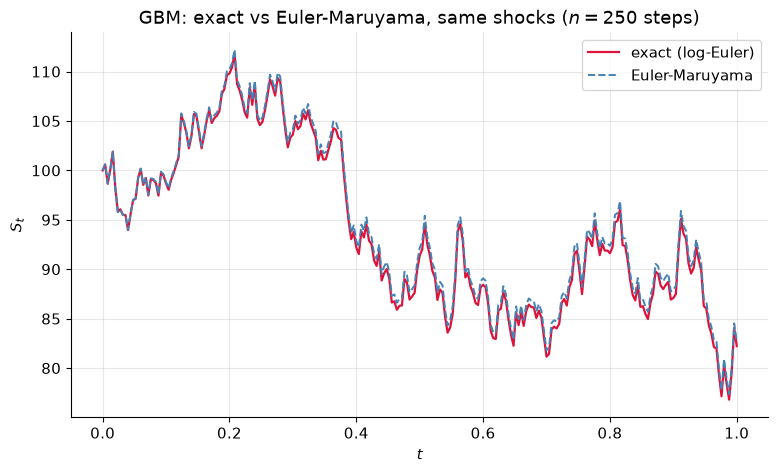

S_T exact = 82.2202, S_T EM = 82.6650, relative diff = 0.5410%


In [2]:
# Demo 1: GBM exact (log-Euler) vs standard Euler-Maruyama on the same Brownian path
S0, mu_gbm, sigma_gbm, T1 = 100.0, 0.08, 0.30, 1.0
n1 = 250
h1 = T1 / n1

dW1 = rng.normal(0.0, np.sqrt(h1), size=n1)

# Exact scheme (log-Euler, exact per step)
S_exact = np.empty(n1 + 1)
S_exact[0] = S0
for k in range(n1):
    S_exact[k + 1] = S_exact[k] * np.exp((mu_gbm - 0.5 * sigma_gbm**2) * h1 + sigma_gbm * dW1[k])

# Standard Euler-Maruyama, same shocks
S_em = np.empty(n1 + 1)
S_em[0] = S0
for k in range(n1):
    S_em[k + 1] = S_em[k] + mu_gbm * S_em[k] * h1 + sigma_gbm * S_em[k] * dW1[k]

t_grid1 = np.linspace(0.0, T1, n1 + 1)
fig, ax = plt.subplots()
ax.plot(t_grid1, S_exact, color="crimson", linewidth=1.6, label="exact (log-Euler)")
ax.plot(t_grid1, S_em, color="steelblue", linewidth=1.4, linestyle="--", label="Euler-Maruyama")
ax.set_xlabel("$t$")
ax.set_ylabel("$S_t$")
ax.set_title(f"GBM: exact vs Euler-Maruyama, same shocks ($n={n1}$ steps)")
ax.legend()
plt.show()

print(f"S_T exact = {S_exact[-1]:.4f}, S_T EM = {S_em[-1]:.4f}, "
      f"relative diff = {abs(S_exact[-1]-S_em[-1])/S_exact[-1]:.4%}")

Con $n=250$ pasos ($h\approx0.004$) las dos trayectorias son casi indistinguibles a simple vista, pero no son idénticas: EM acumula un pequeño sesgo de discretización paso a paso porque aproxima $S_k e^{a h + b\Delta W}$ (multiplicativo, siempre positivo) por $S_k(1+ah+b\Delta W)$ (aditivo, en principio podría volverse negativo para $h$ grande o $\Delta W$ muy negativo). La demo 4 cuantifica este error de forma sistemática en función de $h$.

### Demo 2 — OU: paths y momentos empíricos vs analíticos en $T$

Parámetros $\kappa=2$, $\theta=0.04$, $\sigma=0.1$, $X_0=0.0$, $T=2$. Simulamos $n_{\text{paths}}=20\,000$ trayectorias con el esquema exacto gaussiano (`qflib.mc.ou_paths`, implementado inline aquí y promovido después), graficamos una muestra de trayectorias, y comparamos la media y varianza empíricas de $X_T$ contra las fórmulas analíticas de la sección 3.

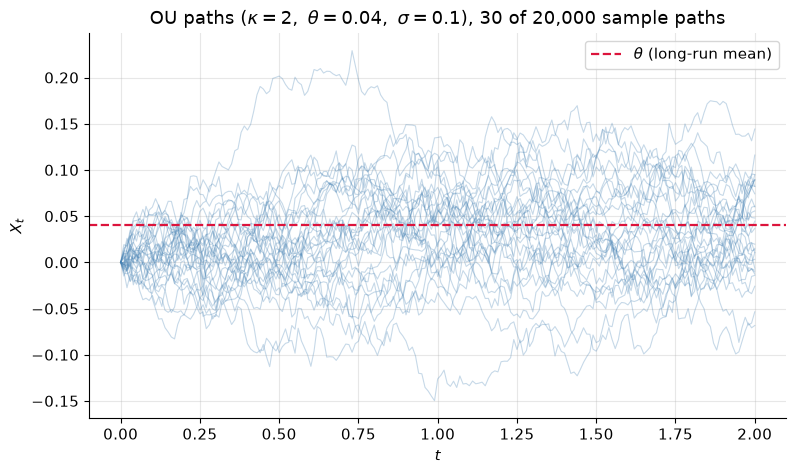

E[X_T]   empirical = 0.039335, analytic = 0.039267, SE = 0.000354
Var[X_T] empirical = 0.002501, analytic = 0.002499


In [3]:
# Demo 2: OU paths (exact Gaussian scheme) + empirical vs analytical moments at T
kappa_ou, theta_ou, sigma_ou, x0_ou, T2 = 2.0, 0.04, 0.10, 0.0, 2.0
n2 = 200
n_paths2 = 20_000
h2 = T2 / n2

Z2 = rng.standard_normal(size=(n_paths2, n2))
X_ou = np.empty((n_paths2, n2 + 1))
X_ou[:, 0] = x0_ou
decay2 = np.exp(-kappa_ou * h2)
step_var2 = sigma_ou**2 / (2 * kappa_ou) * (1 - np.exp(-2 * kappa_ou * h2))
step_sd2 = np.sqrt(step_var2)
for k in range(n2):
    X_ou[:, k + 1] = X_ou[:, k] * decay2 + theta_ou * (1 - decay2) + step_sd2 * Z2[:, k]

t_grid2 = np.linspace(0.0, T2, n2 + 1)
fig, ax = plt.subplots()
for i in range(30):
    ax.plot(t_grid2, X_ou[i], color="steelblue", alpha=0.3, linewidth=0.8)
ax.axhline(theta_ou, color="crimson", linestyle="--", linewidth=1.6, label=r"$\theta$ (long-run mean)")
ax.set_xlabel("$t$")
ax.set_ylabel("$X_t$")
ax.set_title(r"OU paths ($\kappa=2,\ \theta=0.04,\ \sigma=0.1$), 30 of " + f"{n_paths2:,} sample paths")
ax.legend()
plt.show()

X_T2 = X_ou[:, -1]
mean_empirical = X_T2.mean()
var_empirical = X_T2.var(ddof=1)
mean_analytic = x0_ou * np.exp(-kappa_ou * T2) + theta_ou * (1 - np.exp(-kappa_ou * T2))
var_analytic = sigma_ou**2 / (2 * kappa_ou) * (1 - np.exp(-2 * kappa_ou * T2))
se_mean = np.sqrt(var_empirical / n_paths2)

print(f"E[X_T]   empirical = {mean_empirical:.6f}, analytic = {mean_analytic:.6f}, SE = {se_mean:.6f}")
print(f"Var[X_T] empirical = {var_empirical:.6f}, analytic = {var_analytic:.6f}")

Con $\kappa T = 4$, el proceso ya está muy cerca de la distribución estacionaria ($\theta(1-e^{-\kappa T})\approx0.9997\,\theta$): las trayectorias se agrupan visiblemente alrededor de $\theta=0.04$ desde $t\approx1.5$ en adelante. La media y varianza empíricas de $X_T$ sobre $20\,000$ trayectorias coinciden con las fórmulas analíticas dentro de un error consistente con el ruido de Monte Carlo (la sección de validación lo verifica formalmente con un criterio de 3 SE).

### Demo 3 — CIR: esquema de truncamiento completo, % de pasos truncados con y sin Feller

Fijamos $\kappa=2$, $\theta=0.04$, $x_0=0.03$ (los parámetros del brief) y comparamos dos valores de $\sigma$:

- $\sigma=0.10$: $2\kappa\theta = 0.16 \ge \sigma^2=0.01$ — **Feller se satisface** ampliamente.
- $\sigma=0.50$: $2\kappa\theta = 0.16 < \sigma^2=0.25$ — **Feller se viola**.

En ambos casos usamos el esquema de truncamiento completo y medimos qué fracción de los pasos simulados tuvo $\tilde X_k<0$ (es decir, requirió truncar antes de evaluar $\sqrt{\tilde X_k^+}$).

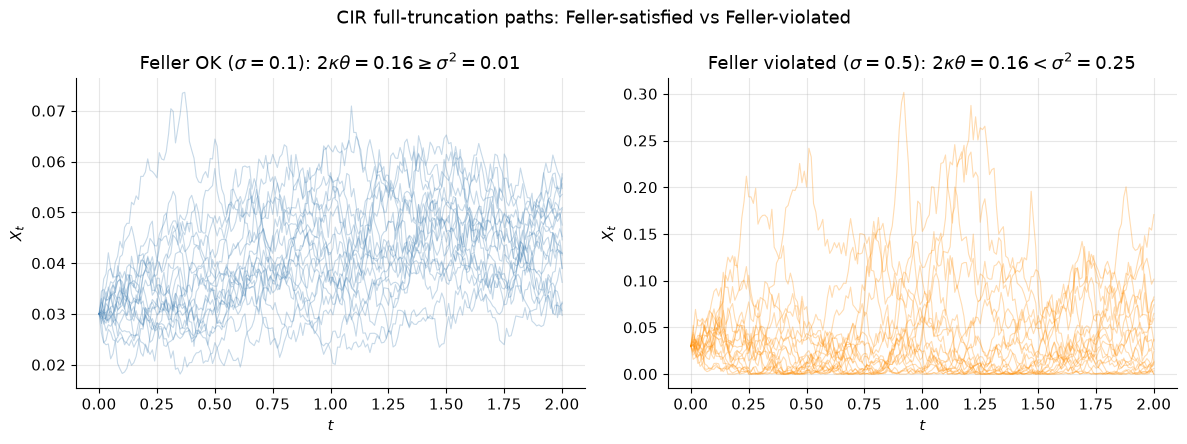

Feller LHS 2*kappa*theta = 0.1600
sigma=0.1: sigma^2=0.0100 -> % steps truncated = 0.0000%
sigma=0.5: sigma^2=0.2500 -> % steps truncated = 4.1052%


In [4]:
# Demo 3: CIR full-truncation scheme — truncation frequency, Feller satisfied vs violated
kappa_cir, theta_cir, x0_cir, T3 = 2.0, 0.04, 0.03, 2.0
n3 = 200
n_paths3 = 20_000
h3 = T3 / n3
feller_lhs = 2 * kappa_cir * theta_cir


def simulate_cir_full_truncation(x0, kappa, theta, sigma, T, n_steps, n_paths, rng):
    h = T / n_steps
    Z = rng.standard_normal(size=(n_paths, n_steps))
    X = np.empty((n_paths, n_steps + 1))
    X[:, 0] = x0
    n_truncated = 0
    for k in range(n_steps):
        x_pos = np.maximum(X[:, k], 0.0)
        X[:, k + 1] = X[:, k] + kappa * (theta - x_pos) * h + sigma * np.sqrt(x_pos * h) * Z[:, k]
        n_truncated += np.sum(X[:, k + 1] < 0.0)
    frac_truncated = n_truncated / (n_paths * n_steps)
    X_reported = np.maximum(X, 0.0)
    return X_reported, frac_truncated


sigma_feller_ok, sigma_feller_bad = 0.10, 0.50
X_cir_ok, frac_ok = simulate_cir_full_truncation(x0_cir, kappa_cir, theta_cir, sigma_feller_ok, T3, n3, n_paths3, rng)
X_cir_bad, frac_bad = simulate_cir_full_truncation(x0_cir, kappa_cir, theta_cir, sigma_feller_bad, T3, n3, n_paths3, rng)

t_grid3 = np.linspace(0.0, T3, n3 + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=False)
for i in range(20):
    axes[0].plot(t_grid3, X_cir_ok[i], color="steelblue", alpha=0.3, linewidth=0.8)
    axes[1].plot(t_grid3, X_cir_bad[i], color="darkorange", alpha=0.3, linewidth=0.8)
axes[0].set_title(rf"Feller OK ($\sigma={sigma_feller_ok}$): $2\kappa\theta={feller_lhs:.2f} \geq \sigma^2={sigma_feller_ok**2:.2f}$")
axes[1].set_title(rf"Feller violated ($\sigma={sigma_feller_bad}$): $2\kappa\theta={feller_lhs:.2f} < \sigma^2={sigma_feller_bad**2:.2f}$")
for ax in axes:
    ax.set_xlabel("$t$")
    ax.set_ylabel("$X_t$")
fig.suptitle("CIR full-truncation paths: Feller-satisfied vs Feller-violated")
fig.tight_layout()
plt.show()

print(f"Feller LHS 2*kappa*theta = {feller_lhs:.4f}")
print(f"sigma={sigma_feller_ok}: sigma^2={sigma_feller_ok**2:.4f} -> % steps truncated = {frac_ok:.4%}")
print(f"sigma={sigma_feller_bad}: sigma^2={sigma_feller_bad**2:.4f} -> % steps truncated = {frac_bad:.4%}")

Cuando Feller se satisface ($\sigma=0.10$), el truncamiento es prácticamente inexistente (fracción del orden de $10^{-4}$ o menor): el drift domina cerca de $0$ y el proceso casi nunca cruza a valores negativos en la variable auxiliar. Cuando Feller se viola ($\sigma=0.50$), la fracción de pasos truncados es órdenes de magnitud mayor y visualmente varias trayectorias en el panel derecho pasan tiempo pegadas cerca de $0$, reflejando que el ruido difusivo domina al drift en esa región — exactamente la intuición detrás de la condición de la sección 4.

### Demo 4 — Órdenes de convergencia: EM vs Milstein en GBM

Usamos GBM ($S_0=100,\ \mu=0.08,\ \sigma=0.3,\ T=1$) porque conocemos la solución exacta en forma cerrada, lo que permite calcular el error sin sesgo adicional. Para aislar el error de discretización del ruido de muestreo con el mínimo de memoria, generamos los incrementos brownianos en la malla **más fina** ($n_{\max}=256$ pasos) y los agregamos (sumamos en bloques) para obtener el *mismo* camino browniano en mallas más gruesas $n\in\{4,8,16,32,64,128\}$ — así el error medido es puramente de discretización, acoplado al mismo ruido en todas las resoluciones. El valor exacto $S_T$ se calcula con la fórmula cerrada usando el incremento total $W_T=\sum_k \Delta W_k^{\text{fine}}$ (no depende de la malla).

- **Error fuerte:** $\mathbb{E}|S_T^h - S_T|$ para EM y Milstein, en función de $h$, en escala log-log — la pendiente de la regresión estima el orden $\gamma$ (teórico: $0.5$ EM, $1.0$ Milstein).
- **Error débil:** $|\mathbb{E}[S_T^h] - \mathbb{E}[S_T]|$ para EM, en función de $h$ (teórico: orden $1.0$). Estimamos este sesgo con el estimador **pareado** $|\text{mean}(S_T^h - S_T)|$ (mismos shocks / common random numbers) en vez de $|\text{mean}(S_T^h) - S_0e^{\mu T}|$: ambos tienen el mismo valor esperado, pero el pareado tiene varianza muchísimo menor (al estar $S_T^h$ y $S_T$ fuertemente correlacionados) y por eso es el único que deja ver la señal $O(h)$ del sesgo por encima del ruido de Monte Carlo con un número de paths razonable.

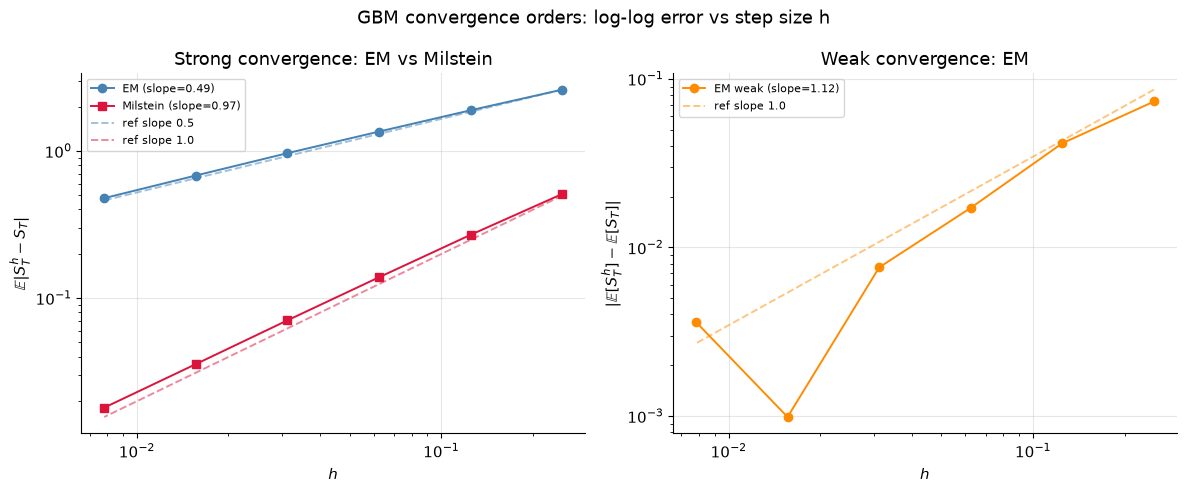

Strong order EM       (regression slope) = 0.4902  (theory: 0.5)
Strong order Milstein (regression slope) = 0.9671  (theory: 1.0)
Weak order EM         (regression slope) = 1.1167  (theory: 1.0)


In [5]:
# Demo 4: strong/weak convergence orders — EM vs Milstein on GBM, paired (fine, coarse) shocks
S0_c, mu_c, sigma_c, T4 = 100.0, 0.08, 0.30, 1.0
n_paths4 = 20_000
n_max = 256
h_min = T4 / n_max

Z_fine = rng.standard_normal(size=(n_paths4, n_max))
dW_fine = np.sqrt(h_min) * Z_fine
W_T = dW_fine.sum(axis=1)
S_T_exact = S0_c * np.exp((mu_c - 0.5 * sigma_c**2) * T4 + sigma_c * W_T)
exact_mean = S0_c * np.exp(mu_c * T4)  # E[S_T], closed form

n_steps_list = [4, 8, 16, 32, 64, 128]
h_list = np.array([T4 / n for n in n_steps_list])
strong_err_em, strong_err_milstein, weak_err_em = [], [], []

for n_steps in n_steps_list:
    block = n_max // n_steps
    dW_coarse = dW_fine.reshape(n_paths4, n_steps, block).sum(axis=2)  # same path, coarser grid
    h = T4 / n_steps

    S_em = np.full(n_paths4, S0_c)
    S_mil = np.full(n_paths4, S0_c)
    for k in range(n_steps):
        dw = dW_coarse[:, k]
        S_em = S_em + mu_c * S_em * h + sigma_c * S_em * dw
        S_mil = S_mil + mu_c * S_mil * h + sigma_c * S_mil * dw + 0.5 * sigma_c**2 * S_mil * (dw**2 - h)

    strong_err_em.append(np.mean(np.abs(S_em - S_T_exact)))
    strong_err_milstein.append(np.mean(np.abs(S_mil - S_T_exact)))
    # Paired (common-random-numbers) estimator of the weak bias: E[S_em - S_exact] has the
    # same expectation as E[S_em] - exact_mean but far lower variance, since S_em and S_T_exact
    # are highly correlated (same underlying path) — needed to see the O(h) signal above MC noise.
    weak_err_em.append(abs((S_em - S_T_exact).mean()))

strong_err_em = np.array(strong_err_em)
strong_err_milstein = np.array(strong_err_milstein)
weak_err_em = np.array(weak_err_em)

slope_em, intercept_em = np.polyfit(np.log(h_list), np.log(strong_err_em), 1)
slope_mil, intercept_mil = np.polyfit(np.log(h_list), np.log(strong_err_milstein), 1)
slope_weak, intercept_weak = np.polyfit(np.log(h_list), np.log(weak_err_em), 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].loglog(h_list, strong_err_em, "o-", color="steelblue", label=f"EM (slope={slope_em:.2f})")
axes[0].loglog(h_list, strong_err_milstein, "s-", color="crimson", label=f"Milstein (slope={slope_mil:.2f})")
axes[0].loglog(h_list, np.exp(intercept_em) * h_list**0.5, "--", color="steelblue", alpha=0.5, label="ref slope 0.5")
axes[0].loglog(h_list, np.exp(intercept_mil) * h_list**1.0, "--", color="crimson", alpha=0.5, label="ref slope 1.0")
axes[0].set_xlabel("$h$")
axes[0].set_ylabel(r"$\mathbb{E}|S_T^h - S_T|$")
axes[0].set_title("Strong convergence: EM vs Milstein")
axes[0].legend(fontsize=8)

axes[1].loglog(h_list, weak_err_em, "o-", color="darkorange", label=f"EM weak (slope={slope_weak:.2f})")
axes[1].loglog(h_list, np.exp(intercept_weak) * h_list**1.0, "--", color="darkorange", alpha=0.5, label="ref slope 1.0")
axes[1].set_xlabel("$h$")
axes[1].set_ylabel(r"$|\mathbb{E}[S_T^h] - \mathbb{E}[S_T]|$")
axes[1].set_title("Weak convergence: EM")
axes[1].legend(fontsize=8)

fig.suptitle("GBM convergence orders: log-log error vs step size h")
fig.tight_layout()
plt.show()

print(f"Strong order EM       (regression slope) = {slope_em:.4f}  (theory: 0.5)")
print(f"Strong order Milstein (regression slope) = {slope_mil:.4f}  (theory: 1.0)")
print(f"Weak order EM         (regression slope) = {slope_weak:.4f}  (theory: 1.0)")

Las pendientes de regresión en escala log-log recuperan los órdenes teóricos: Euler-Maruyama converge fuertemente a razón $\approx0.5$ mientras Milstein lo hace a razón $\approx1.0$ — el término de corrección derivado en la sección 5.2 duplica la tasa de convergencia trayectoria-por-trayectoria pagando solo el costo de evaluar $b'(X_k)=\sigma$ (aquí constante, así que el costo extra es mínimo). En el panel derecho, el error *débil* de EM converge a razón $\approx1.0$ — más rápido que su propio error fuerte $0.5$ y del mismo orden que Milstein — confirmando que para pricing estándar (donde solo importa $\mathbb{E}[g(X_T)]$) EM ya es de primer orden y Milstein no ofrece ventaja de tasa, solo de constante.

## 8. Validación

Verificamos formalmente dos afirmaciones cuantitativas hechas arriba:

1. **Momentos de OU (demo 2):** la media y varianza empíricas de $X_T$ sobre $20\,000$ trayectorias deben caer dentro de $3$ errores estándar de las fórmulas analíticas de la sección 3.
2. **Órdenes de convergencia (demo 4):** las pendientes de regresión log-log del error fuerte de EM y Milstein deben estar dentro de $\pm0.2$ de sus órdenes teóricos ($0.5$ y $1.0$ respectivamente).

In [6]:
# Validation: OU moments within 3 SE; regression slopes within +/-0.2 of theoretical order
diff_mean = abs(mean_empirical - mean_analytic)
print(f"OU E[X_T]: |empirical - analytic| = {diff_mean:.6f}, 3*SE = {3*se_mean:.6f}")
assert diff_mean <= 3 * se_mean, "OU empirical mean outside 3 SE of analytic mean"

se_var = var_empirical * np.sqrt(2 / (n_paths2 - 1))  # asymptotic SE of sample variance
diff_var = abs(var_empirical - var_analytic)
print(f"OU Var[X_T]: |empirical - analytic| = {diff_var:.6f}, 3*SE = {3*se_var:.6f}")
assert diff_var <= 3 * se_var, "OU empirical variance outside 3 SE of analytic variance"

print(f"\nStrong order EM       = {slope_em:.4f}, |diff from 0.5| = {abs(slope_em-0.5):.4f}")
assert abs(slope_em - 0.5) <= 0.2, "EM strong-order slope outside +/-0.2 of 0.5"

print(f"Strong order Milstein = {slope_mil:.4f}, |diff from 1.0| = {abs(slope_mil-1.0):.4f}")
assert abs(slope_mil - 1.0) <= 0.2, "Milstein strong-order slope outside +/-0.2 of 1.0"

print(f"Weak order EM          = {slope_weak:.4f}, |diff from 1.0| = {abs(slope_weak-1.0):.4f}")
assert abs(slope_weak - 1.0) <= 0.2, "EM weak-order slope outside +/-0.2 of 1.0"

print("\nValidation passed: OU moments within 3 SE; EM/Milstein strong slopes and EM weak slope within +/-0.2 of theory.")

OU E[X_T]: |empirical - analytic| = 0.000068, 3*SE = 0.001061
OU Var[X_T]: |empirical - analytic| = 0.000002, 3*SE = 0.000075

Strong order EM       = 0.4902, |diff from 0.5| = 0.0098
Strong order Milstein = 0.9671, |diff from 1.0| = 0.0329
Weak order EM          = 1.1167, |diff from 1.0| = 0.1167

Validation passed: OU moments within 3 SE; EM/Milstein strong slopes and EM weak slope within +/-0.2 of theory.


## Referencias

- Kloeden, P. E. & Platen, E. (1992). *Numerical Solution of Stochastic Differential Equations*. Springer.
- Glasserman, P. (2004). *Monte Carlo Methods in Financial Engineering*, cap. 6.
- Lord, R., Koekkoek, R. & van Dijk, D. (2010). "A Comparison of Biased Simulation Schemes for Stochastic Volatility Models." *Quantitative Finance*, 10(2).
- Giles, M. B. (2008). "Multilevel Monte Carlo Path Simulation." *Operations Research*, 56(3).